# CSI 4124 / SYS 5110 — Assignment 1

**Foundation of Modelling and Simulation — Fall 2026**

**Team members:** < name 1 >, < name 2 >, < name 3 >, < name 4 >

In [7]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

## A1.1 Integrating the SIS model

### a. Explicit Euler, RK2 and RK4 integrators


In [8]:
# Single-step functions

def euler_step(f, x, t, h):
    return x + h * f(x, t)

def rk2_step(f, x, t, h):
    k1 = f(x, t)
    k2 = f(x + 0.5 * h * k1, t + 0.5 * h)
    return x + h * k2

def rk4_step(f, x, t, h):
    k1 = f(x, t)
    k2 = f(x + 0.5 * h * k1, t + 0.5 * h)
    k3 = f(x + 0.5 * h * k2, t + 0.5 * h)
    k4 = f(x + h * k3, t + h)
    return x + (h / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)


# Driver for an initial value problem dx/dt = f(x, t), x(0) = x0.
#   step : one of the single-step functions

# Returns
#   t : array of the M+1 times t_j = j*h
#   x : array of the M+1 states x_j

def integrate(step, f, x0, T, M):
    h = T / M
    t = np.linspace(0.0, T, M + 1)
    x0 = np.asarray(x0, dtype=float)
    x = np.empty((M + 1,) + x0.shape)
    x[0] = x0
    for j in range(M):
        x[j + 1] = step(f, x[j], t[j], h)
    return t, x


def euler(f, x0, T, M): return integrate(euler_step, f, x0, T, M)
def rk2(f, x0, T, M):   return integrate(rk2_step,   f, x0, T, M)
def rk4(f, x0, T, M):   return integrate(rk4_step,   f, x0, T, M)

integrators = {"Euler": euler, "RK2": rk2, "RK4": rk4}

In [9]:

N  = 1e5 # population size
i0 = 10.0 # initial number of infectious
R0 = 1.5 # basic reproduction number
K  = N * (1.0 - 1.0 / R0) # endemic level appearing in Eq. (3)

def sis_rhs(i, t):
    return (R0 - 1.0) * i - R0 * i**2 / N

def sis_exact(t):
    e = np.exp((R0 - 1.0) * t)
    return K * i0 * e / (K + i0 * (e - 1.0))

**Integration.** We integrate to $T = 40$ with $M = 4000$ steps ($h = 10^{-2}$) with each method, and compute the absolute error $|i_j - i(t_j)|$ at every time point.

In [10]:
T, M = 40.0, 4000
h = T / M


results = {name: integ(sis_rhs, i0, T, M) for name, integ in integrators.items()}

t = results["Euler"][0]
i_exact = sis_exact(t)

errors = {name: np.abs(i_num - i_exact) for name, (_, i_num) in results.items()}
print(f"h = {h}")
for name, err in errors.items():
    print(f"{name:6s}  max error = {err.max():.2e}   (at t = {t[err.argmax()]:.2f})   error at T = {err[-1]:.2e}")

h = 0.01
Euler   max error = 1.40e+02   (at t = 16.24)   error at T = 2.16e-03
RK2     max error = 2.03e-01   (at t = 16.14)   error at T = 1.48e-05
RK4     max error = 2.61e-07   (at t = 16.26)   error at T = 1.46e-11


**Figure 1: Trajectories.** The three numerical trajectories are drawn on top of the exact solution (thick grey line). The dotted horizontal line marks the endemic level $K$.

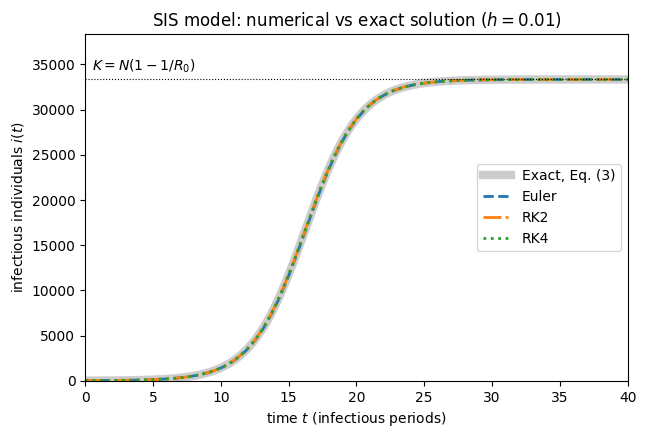

In [11]:
styles = {"Euler": dict(ls="--"), "RK2": dict(ls="-."), "RK4": dict(ls=":")}

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(t, i_exact, color="grey", lw=6, alpha=0.4, label="Exact, Eq. (3)")
for name, (t_num, i_num) in results.items():
    ax.plot(t_num, i_num, lw=2, label=name, **styles[name])
ax.axhline(K, color="k", lw=0.8, ls=":")
ax.text(0.5, K * 1.03, r"$K = N(1-1/R_0)$")
ax.set_xlabel(r"time $t$ (infectious periods)")
ax.set_ylabel(r"infectious individuals $i(t)$")
ax.set_title(rf"SIS model: numerical vs exact solution ($h = {h:g}$)")
ax.set_xlim(0, T)
ax.set_ylim(0, 1.15 * K)
ax.legend(loc="center right")
plt.show()

**Figure 2: Absolute error.** Same integrations, but now we show $|i_j - i(t_j)|$ on a semi-logarithmic scale. The point $t_0 = 0$ is omitted since the error is exactly zero there.

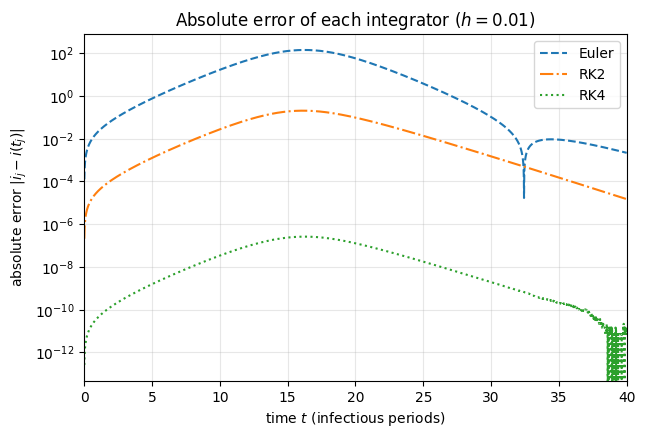

In [12]:
fig, ax = plt.subplots(figsize=(7, 4.5))
for name, err in errors.items():
    ax.semilogy(t[1:], err[1:], lw=1.5, label=name, **styles[name])
ax.set_xlabel(r"time $t$ (infectious periods)")
ax.set_ylabel(r"absolute error $|i_j - i(t_j)|$")
ax.set_title(rf"Absolute error of each integrator ($h = {h:g}$)")
ax.set_xlim(0, T)
ax.grid(True, which="major", alpha=0.3)
ax.legend()
plt.show()

**Discussion.**

**Figure 1.** With $h = 10^{-2}$, the three numerical trajectories are almost identical to the exact solution as $i(t)$ grows rapidly, then levels off at the endemic level $K \approx 3.3\times10^4$. At this scale, the difference between each method is not visible.

**Figure 2.** The semi-log error plot shows that the numerical errors very different:

- Euler has the largest error, reaching around $10^{2}$ individuals.
- RK2 is substantially better, with a max error of about $10^{-1}$.
- RK4 is dramatically more accurate, with a maximum error of about $10^{-7}$.

This ordering is consistent with the global errors seen in class, $O(h)$, $O(h^2)$ and $O(h^4)$ as the higher the order of the method, the smaller the error for the same step size $h$. Because these errors are different depending on the orders of magnitude, they can only be compared on a logarithmic scale, which is what the second plot shows that the first one does not.

The plot also shows how the error evolves in time. For all three methods, the error increases during the rapid-growth phase of the epidemic which reaches a maximum around $t \approx 16$, where $i(t)$ changes fastest, and then decreases as the solution approaches $K$, where it changes very little from one step to the next.